# Model Explainability & Business Insights

## Objective

This notebook explains how the fraud detection model makes decisions.

Key Goals:

- Understand model behavior
- Identify key fraud indicators
- Generate feature importance rankings
- Apply SHAP Explainability
- Produce business-friendly fraud insights
- Support regulatory and audit requirements

Business Value:
Financial institutions require transparent AI systems. Explainability helps risk teams understand why a transaction was flagged as fraudulent.

In [32]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

import shap

plt.style.use("default")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [33]:
df = pd.read_csv(
    "../data/processed/fraud_processed.csv"
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (6362620, 24)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,balance_error_org,balance_error_dest,customer_type,merchant_type,age_group,customer_segment,channel,device_type,risk_region,account_tenure_months
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,...,1.455192e-11,-9839.64,C,M,26-35,Retail,Mobile App,iPhone,Central,20
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,...,-1.136868e-12,-1864.28,C,M,60+,Retail,Internet Banking,Android,East,7
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,...,0.000000e+00,-181.00,C,C,36-45,Retail,Internet Banking,Desktop,East,39
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,...,0.000000e+00,-21363.00,C,C,36-45,Premium,Mobile App,Android,North,116
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,...,0.000000e+00,-11668.14,C,M,18-25,Retail,Internet Banking,iPhone,East,19


In [34]:
model = joblib.load(
    "../models/random_forest_fraud_detector.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [35]:
df = df.drop(
    columns=[
        "nameOrig",
        "nameDest"
    ]
)

print(df.shape)

(6362620, 22)


In [36]:
X = df.drop(
    columns=["isFraud"]
)

y = df["isFraud"]

print(X.shape)

(6362620, 21)


In [37]:
from sklearn.preprocessing import LabelEncoder
categorical_cols = [
    "type",
    "customer_type",
    "merchant_type",
    "age_group",
    "customer_segment",
    "channel",
    "device_type",
    "risk_region"
]

for col in categorical_cols:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

print("Encoding Complete")

Encoding Complete


### Which variables contribute most to fraud prediction?

In [38]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
11,balance_error_org,0.318205
3,oldbalanceOrg,0.130729
4,newbalanceOrig,0.126743
2,amount,0.099402
1,type,0.092873
14,merchant_type,0.057772
12,balance_error_dest,0.041225
0,step,0.029487
8,transaction_hour,0.028816
6,newbalanceDest,0.027523


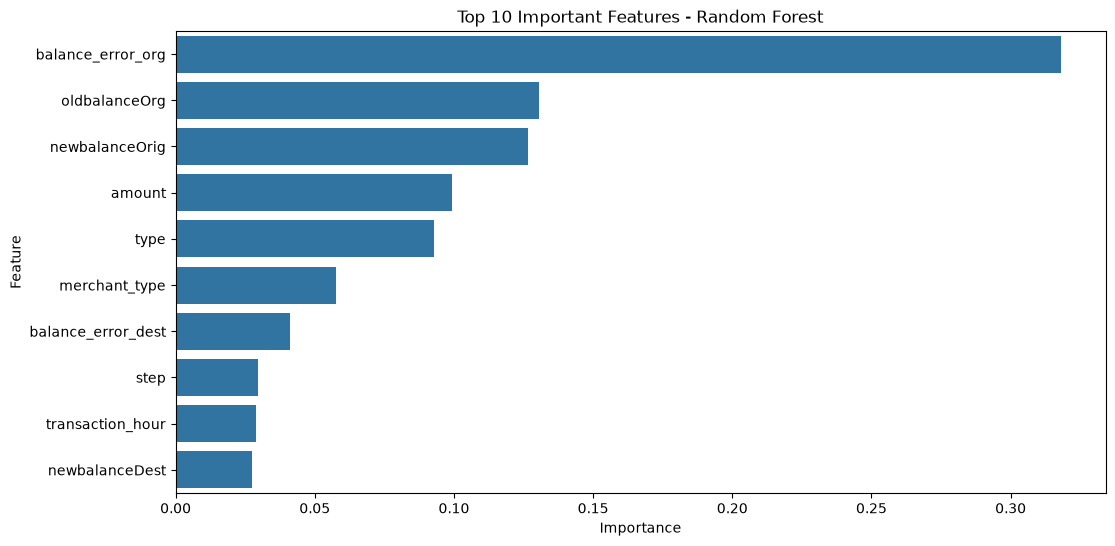

In [39]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Important Features - Random Forest"
)

plt.show()

## Key Findings

1. balance_error_org is the strongest fraud indicator.
2. Fraudulent transactions frequently involve abnormal balance changes.
3. Transaction amount strongly influences fraud prediction.
4. Transaction type is an important fraud driver.
5. Merchant interactions contribute significantly to risk scoring.

Business Insight:
Fraud is primarily associated with transaction behavior and balance inconsistencies rather than customer demographics.

In [40]:
shap_sample = X.sample(
    5000,
    random_state=42
)

print(shap_sample.shape)

(5000, 21)


In [41]:
explainer = shap.TreeExplainer(model)

In [42]:
shap_values = explainer.shap_values(
    shap_sample
)

print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(5000, 21, 2)


In [43]:
shap_fraud = shap_values[:,:,1]

print(shap_fraud.shape)

(5000, 21)


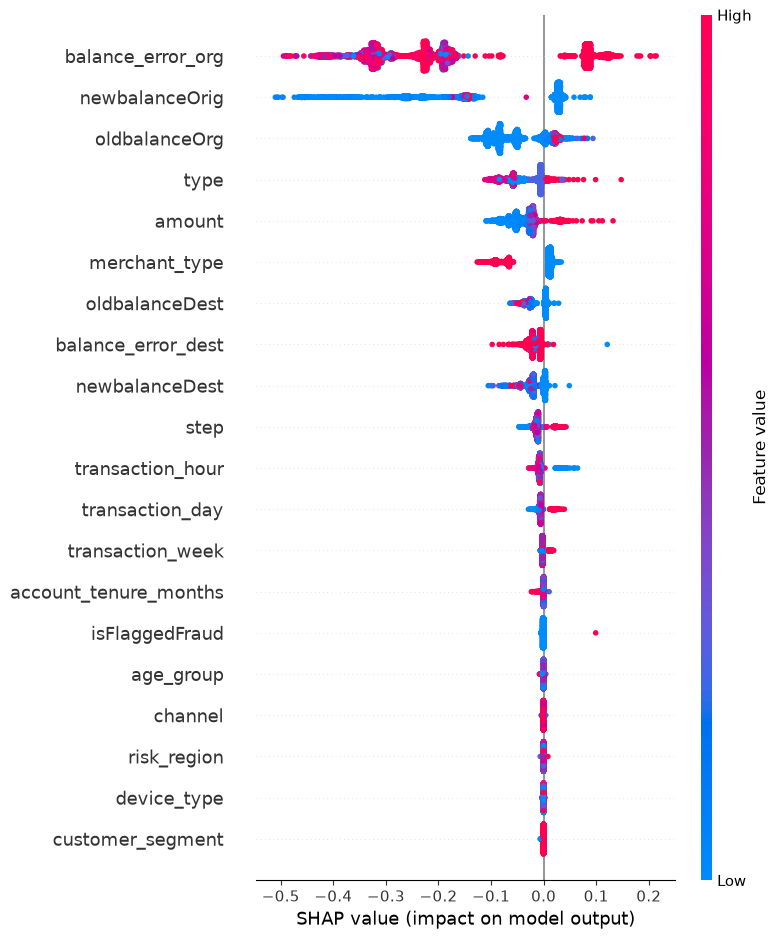

In [44]:
shap.summary_plot(
    shap_fraud,
    shap_sample
)

In [45]:
shap_importance = pd.DataFrame({

    "Feature": shap_sample.columns,

    "Mean_SHAP": np.abs(
        shap_fraud
    ).mean(axis=0)

})

shap_importance = shap_importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)

shap_importance.head(15)

,Feature,Mean_SHAP
11,balance_error_org,0.230612
4,newbalanceOrig,0.107432
3,oldbalanceOrg,0.059879
1,type,0.040144
2,amount,0.039865
14,merchant_type,0.035702
5,oldbalanceDest,0.018959
12,balance_error_dest,0.017892
6,newbalanceDest,0.016970
0,step,0.014631


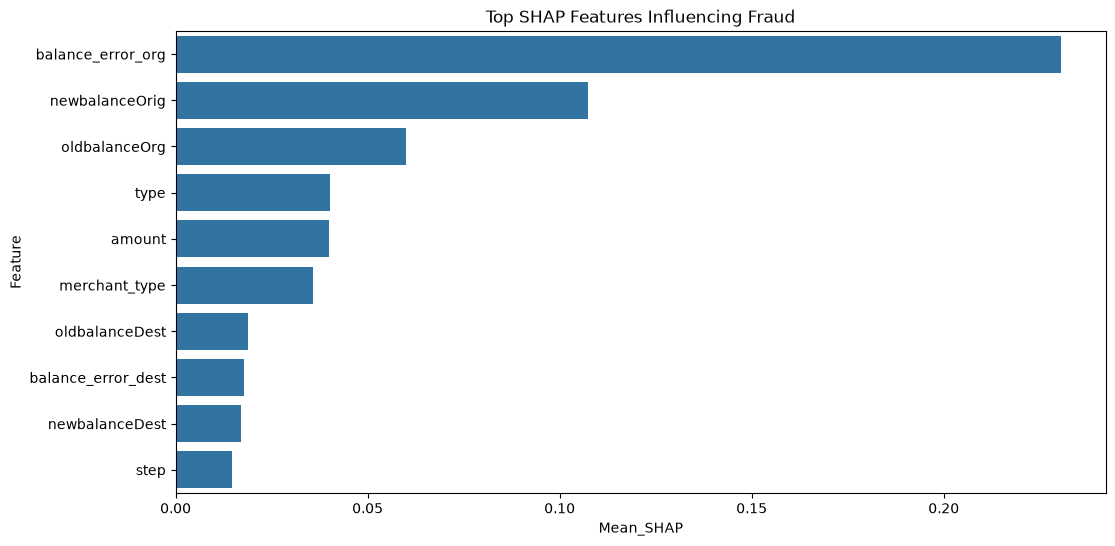

In [46]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=shap_importance.head(10),
    x="Mean_SHAP",
    y="Feature"
)

plt.title(
    "Top SHAP Features Influencing Fraud"
)

plt.show()

## Executive Insights

### Major Fraud Drivers

- Balance inconsistencies
- High-value transactions
- Transaction type
- Merchant-related transfers

### Operational Recommendations

1. Monitor large balance deviations.
2. Flag unusual transfer patterns.
3. Introduce enhanced verification for high-risk transaction types.
4. Prioritize real-time monitoring of merchant-related transfers.

### Model Governance

The fraud detection system is explainable and transparent through SHAP analysis, supporting compliance, auditability, and stakeholder trust.

In [47]:
feature_importance.to_csv(
    "../reports/random_forest_feature_importance.csv",
    index=False
)

shap_importance.to_csv(
    "../reports/shap_feature_importance.csv",
    index=False
)

print("Explainability Reports Saved")

Explainability Reports Saved
